In [1]:
# Import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
from time import sleep
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry

# Function to scrape a URL and extract table data
def scrape_table(url, year, session):
    try:
        # Use session with retry strategy
        response = session.get(url, headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'})
        response.raise_for_status()

        soup = BeautifulSoup(response.text, 'html.parser')
        table = soup.find('table', id='combine')  # Target Combine table

        if table is None:
            print(f"No Combine table found at {url}")
            return None, None

        # Extract headers from thead
        header_row = table.find('thead')
        if not header_row:
            print(f"No header row found for {year}")
            return None, None
        headers = [th.text.strip() for th in header_row.find_all('th')]

        # Extract rows from tbody
        body = table.find('tbody')
        if not body:
            print(f"No body found for {year}")
            return None, None
        rows = []
        for tr in body.find_all('tr'):
            # Get Player from <th>
            player_cell = tr.find('th')
            if not player_cell:
                continue  # Skip rows without a player
            player = player_cell.text.strip()

            # Get remaining columns from <td>
            cells = [td.text.strip() for td in tr.find_all('td')]
            if not cells:  # Skip if no data
                continue

            # Combine: Player + other columns + Year
            row = [player] + cells + [year]
            rows.append(row)

        print(f"Headers: {len(headers)}, Data columns: {len(rows[0]) if rows else 0}")
        return headers, rows

    except requests.RequestException as e:
        print(f"Request error for {url}: {e}")
        return None, None
    except Exception as e:
        print(f"Unexpected error for {year}: {e}")
        return None, None

# Set up a session with retry strategy
session = requests.Session()
retry_strategy = Retry(
    total=3,  # Retry up to 3 times
    status_forcelist=[429],  # Retry on 429 errors
    backoff_factor=2,  # Wait 2, 4, 8 seconds between retries
    raise_on_status=False  # Don't raise an exception if retries fail
)
adapter = HTTPAdapter(max_retries=retry_strategy)
session.mount("https://", adapter)

# Scrape data
all_data = []
headers = None

for year in range(2000, 2026):
    url = f"https://www.pro-football-reference.com/draft/{year}-combine.htm"
    print(f"Scraping data for {year}...")
    year_headers, year_rows = scrape_table(url, year, session)

    if year_headers and year_rows:
        if headers is None:  # Set headers from first successful year
            headers = year_headers
            print(f"Initial headers set from {year}: {headers}")

        # Check column alignment
        expected_cols = len(headers) + 1  # +1 for Year
        for row in year_rows:
            if len(row) != expected_cols:
                print(f"Column mismatch for {year}: Expected {expected_cols}, Got {len(row)}, Row: {row}")
                # Pad or trim to match headers
                if len(row) < expected_cols:
                    row.extend([None] * (expected_cols - len(row)))
                elif len(row) > expected_cols:
                    row = row[:expected_cols]
            all_data.append(row)

        print(f"Successfully scraped {len(year_rows)} players for {year}")

    # Increased delay to avoid rate limiting
    sleep(5)  # Wait 5 seconds between requests

# Create DataFrame and save
if all_data:
    headers.append('Year')  # Add 'Year' to headers
    print(f"Final headers: {len(headers)}, Sample row columns: {len(all_data[0])}")
    df = pd.DataFrame(all_data, columns=headers)
else:
    print("No data collected. Check the website structure or connectivity.")

Scraping data for 2000...
Headers: 13, Data columns: 14
Initial headers set from 2000: ['Player', 'Pos', 'School', 'College', 'Ht', 'Wt', '40yd', 'Vertical', 'Bench', 'Broad Jump', '3Cone', 'Shuttle', 'Drafted (tm/rnd/yr)']
Successfully scraped 321 players for 2000
Scraping data for 2001...
Headers: 13, Data columns: 14
Successfully scraped 321 players for 2001
Scraping data for 2002...
Headers: 13, Data columns: 14
Successfully scraped 320 players for 2002
Scraping data for 2003...
Headers: 13, Data columns: 14
Successfully scraped 319 players for 2003
Scraping data for 2004...
Headers: 13, Data columns: 14
Successfully scraped 335 players for 2004
Scraping data for 2005...
Headers: 13, Data columns: 14
Successfully scraped 331 players for 2005
Scraping data for 2006...
Headers: 13, Data columns: 14
Successfully scraped 328 players for 2006
Scraping data for 2007...
Headers: 13, Data columns: 14
Successfully scraped 326 players for 2007
Scraping data for 2008...
Headers: 13, Data colu

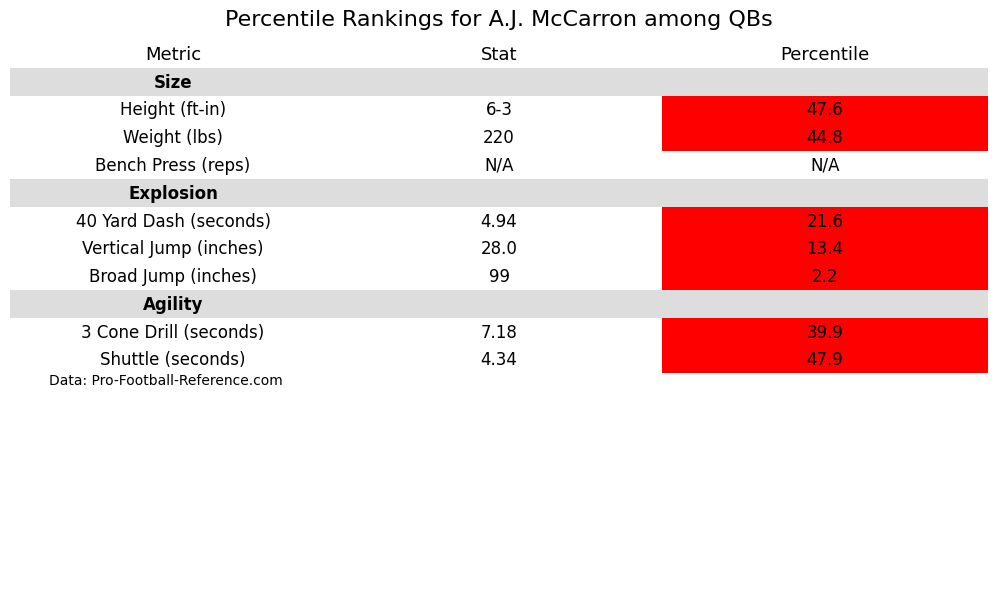

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

# Assume df is your DataFrame with 'Player', 'School', and other columns
# Example: df = pd.DataFrame({'Player': ['Justin Jefferson', 'Joe Burrow'], 'School': ['LSU', 'LSU'], ...})

# Function to convert height string to inches
def height_to_inches(height_str):
    """Convert height string like '6-3' to total inches (e.g., 75)."""
    try:
        if pd.isna(height_str) or not height_str:
            return np.nan
        height_str = str(height_str).strip()
        feet, inches = map(int, height_str.split('-'))
        return feet * 12 + inches
    except (ValueError, AttributeError):
        return np.nan

def create_grid_graphic(player_name, percentiles_dict, position, player_row):
    if percentiles_dict is None:
        print(f"No data to plot for {player_name}")
        return

    metric_labels = {
        'Ht': ('Height (ft-in)', 'Size'),
        'Wt': ('Weight (lbs)', 'Size'),
        'Bench': ('Bench Press (reps)', 'Size'),
        '40yd': ('40 Yard Dash (seconds)', 'Explosion'),
        'Vertical': ('Vertical Jump (inches)', 'Explosion'),
        'Broad Jump': ('Broad Jump (inches)', 'Explosion'),
        '3Cone': ('3 Cone Drill (seconds)', 'Agility'),
        'Shuttle': ('Shuttle (seconds)', 'Agility')
    }

    grouped_data = {'Size': [], 'Explosion': [], 'Agility': []}

    for metric, (label, group) in metric_labels.items():
        stat_val = str(player_row[metric]) if pd.notna(player_row[metric]) else 'N/A'
        perc_val = percentiles_dict.get(metric, None)
        perc_str = f"{perc_val}" if perc_val is not None else 'N/A'
        grouped_data[group].append((label, stat_val, perc_val, perc_str))

    table_data = []
    group_row_indices = {}

    for group, rows in grouped_data.items():
        group_header_index = len(table_data)
        table_data.append([group, "", ""])
        group_row_indices[group_header_index] = True

        for label, stat_val, perc_val, perc_str in rows:
            table_data.append([label, stat_val, perc_str])

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')
    plt.title(f"Percentile Rankings for {player_name} among {position}s", fontsize=16, pad=2)
    text = fig.text(0.05, 0.35, 'Data: Pro-Football-Reference.com', horizontalalignment='left', wrap=True )
    col_labels = ['Metric', 'Stat', 'Percentile']
    table = ax.table(cellText=table_data,
                     colLabels=col_labels,
                     cellLoc='center',
                     loc='upper center')

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.4)

    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0)

        if row == 0:
            cell.set_facecolor('white')
            cell.set_fontsize(13)
            continue

        data_row = row - 1

        if data_row in group_row_indices:
            cell.set_facecolor('#dddddd')
            if col == 0:
                cell.get_text().set_weight('bold')
            else:
                cell.get_text().set_text("")
        else:
            if col == 2:
                value = table_data[data_row][2]
                try:
                    value_num = float(value.replace('%', ''))
                except:
                    value_num = None

                if value_num is None or pd.isna(value_num):
                    cell.set_facecolor('white')
                elif value_num < 50:
                    cell.set_facecolor('red')
                elif 50 <= value_num <= 75:
                    cell.set_facecolor('yellow')
                elif 75 < value_num <= 87.5:
                    cell.set_facecolor('lightgreen')
                else:
                    cell.set_facecolor('green')
            else:
                stat = table_data[data_row][col]
                if stat == '':
                    cell.get_text().set_text("N/A")
                cell.set_facecolor('white')

    plt.subplots_adjust(top=0.98)
    plt.tight_layout()
    plt.show()

def process_selected_player(player_row):
    """Processes the selected player and calculates percentiles, then displays the grid."""
    clear_output(wait=True)  # Clear selection UI

    player_name = player_row['Player']
    position = player_row['Pos']

    player_metrics = ['Ht', 'Wt', '40yd', 'Vertical', 'Bench', 'Broad Jump', '3Cone', 'Shuttle']
    percentiles_dict = {}

    pos_df = df[df['Pos'] == position].copy()

    for metric in player_metrics:
        if metric == 'Ht':
            pos_df['Ht_in'] = pd.to_numeric(pos_df['Ht'].apply(height_to_inches), errors='coerce')
            metric_data = pos_df['Ht_in'].dropna()
            player_value = height_to_inches(player_row['Ht'])
        else:
            pos_df[metric] = pd.to_numeric(pos_df[metric], errors='coerce').astype(float)
            pos_df[metric] = pos_df[metric].replace(0, pd.NA)
            metric_data = pos_df[metric].dropna()
            player_value = pd.to_numeric(player_row[metric], errors='coerce')

        if metric_data.empty:
            percentiles_dict[metric] = None
            continue

        if pd.isna(player_value):
            percentiles_dict[metric] = None
        else:
            if metric in ['40yd', '3Cone', 'Shuttle']:
                percentile = (metric_data > player_value).mean()
            else:
                percentile = (metric_data < player_value).mean()

            percentiles_dict[metric] = round(percentile * 100, 1)


    create_grid_graphic(player_name, percentiles_dict, position, player_row)

def rate(player_name):
    clear_output(wait=True)  # Clear previous output

    df['Player'] = df['Player'].astype('string').str.strip()
    player_rows = df[df['Player'] == player_name]

    if player_rows.empty:
        print(f"{player_name} not found in dataset")
        return

    if len(player_rows) > 1:
        print(f"Multiple players named {player_name} found. Select one:")

        buttons = []
        for _, row in player_rows.iterrows():
            button_label = f"{row['Player']} - {row['Pos']} - Draft Year {row['Year']}"
            button = widgets.Button(description=button_label, layout=widgets.Layout(width='50%'))
            button.on_click(lambda b, r=row: process_selected_player(r))
            buttons.append(button)

        display(*buttons)
    else:
        process_selected_player(player_rows.iloc[0])

# Prepare the dropdown options in the format "Player, School"
df['Dropdown_Label'] = df['Player'] + ', ' + df['School'].astype(str)
all_players = [''] + sorted(df['Dropdown_Label'].dropna().unique())

# Create an output widget to display filtered results
output = widgets.Output()

# Create a text input for filtering
filter_input = widgets.Text(
    value='',
    description='Filter:',
    layout={'width': '50%', 'margin': '0 0 10px 0'}
)

# Create a dropdown for selection with "Player, School" format
player_dropdown = widgets.Dropdown(
    options=all_players,
    description='Select a player:',
    layout={'width': '50%'},
    style={'description_width': 'initial'}
)

# Function to update filtered results and dropdown options
def on_filter_change(change):
    with output:
        clear_output()
        search_term = change['new'].strip()
        if search_term:
            search_term_lower = search_term.lower()
            filtered_df = df[df['Player'].str.lower().str.startswith(search_term_lower, na=False)][['Player', 'School']]
            if not filtered_df.empty:
                display(filtered_df)
                # Update dropdown with filtered "Player, School" labels
                filtered_labels = [''] + sorted(filtered_df['Player'] + ', ' + filtered_df['School'].astype(str))
                player_dropdown.options = filtered_labels
            else:
                print(f"No players found starting with '{search_term}'")
                player_dropdown.options = ['']
        else:
            print("Type a player's name to filter")
            player_dropdown.options = all_players

# Function to handle dropdown selection
def on_dropdown_change(change):
    selected_label = change['new']
    if selected_label:
        # Extract the player name (before the comma)
        player_name = selected_label.split(',')[0].strip()
        # Clear the filter input and output
        filter_input.value = ''
        with output:
            clear_output()
        rate(player_name)

# Observe changes in the filter input and dropdown
filter_input.observe(on_filter_change, names='value')
player_dropdown.observe(on_dropdown_change, names='value')

# Display the filter input, output, and dropdown
display(filter_input)
display(output)
display(player_dropdown)